# Clustering

Clustering is a branch of unsupervised machine learning models that seeks to learn from the properties of the data by identifying groups or clusters in the dataset. Clustering is different from classification as it seeks to identify a set of similar data points and calling the resulting set a cluster. Selecting an appropriate clustering algorithm is often difficult due to the number of choices available. For a comprehensive survey of clustering algorithms, refer [here](https://link.springer.com/content/pdf/10.1007/s40745-015-0040-1.pdf). The three most popular categories of clustering algorithms are

| Categories               | Clustering Algorithm                                        |
| ------------------------ | ----------------------------------------------------------- |
| Partitional clustering   | divides data objects into non overlapping groups            |
| Hierarchical clustering  | assignments by building a hierarchy                         |
| Density-based clustering | assignments based on the density of data points in a region |

# k-Means Algorithm

The $k$-means algorithm searches for a predetermined number of clusters within an unlabeled dataset and is based on the assumptions that the optimal cluster will have

- “cluster center” which is the mean of all the points belonging to the cluster.
- each point is closer to its own cluster center than to other cluster centers.
Conventional $k$-means algorithm requires only a few steps and follows a two-step process called **Expectation-Maximization** approach. This consists of

- Randomly selecting $k$-centroids or cluster center
- Repeat until converged
    a. E-Step: assign points to the nearest cluster center
    b. M-Step: set the cluster center to the mean
The "E-Step" or "Expectation Step" assigns each data point to its nearest centroid. Then, the "M-Step" or Maximization Step" computes the mean of all the points for each cluster and sets the new centroid. The $k$-means algorithms seeks to find $k$ clusters within a data set. The clusters are chosen to reduce the inertia, the objective function

$$\min_{C_k} \sum_k \sum_{X_k\in C_k} || X_j - \mu_k ||^2$$

, and the centroid of a cluster $\mu_k$ is equal to

$$\mu_k = \frac{1}{|C_k|}\sum_{X_j\in C_k} X_j$$

, where $|C_k|$ is the number of points in cluster $k$.

The cluster assignments are done based on squared Euclidean distance and algorithm tries to minimize the objective function. This process is repeated, iteratively, until the sum of the distance is minimized.

# Implementation

## Import Libraries

In [1]:
# Base Libraries
import pandas as pd
import numpy as np
import missingno
import yfinance as yf

# Plotting
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,6)
plt.style.use('fivethirtyeight')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set display options
pd.set_option('display.max_rows', 5000)
pd.set_option('display.max_columns', 5000)
pd.set_option('display.width', 1000)

## Average True Range (ATR) 

ATR is a technical analysis indicator that measures market volatility by decomposing the entire range of an asset price for that period.

The **true range indicator** is taken as **the greatest of** the following: current high less the current low; the absolute value of the current high less the previous close; and the absolute value of the current low less the previous close. The ATR is then a moving average, generally using 14 days, of the true ranges.

In [3]:
# Function to calculate average true range
def ATR(dataframe, period=21):
    "function to calculate True Range and Average True Range"
    df = dataframe.copy()
    
    df['H-L'] = abs(df['High']-df['Low'])
    df['H-PC'] = abs(df['High']-df['Close'].shift(1))
    df['L-PC'] = abs(df['Low']-df['Close'].shift(1))
    df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1,skipna=False)
    df['ATR'] = df['TR'].rolling(period).mean()
    
    df = df.drop(['H-L','H-PC','L-PC'],axis=1,)
    
    return df['ATR']

In [4]:
# Read components of dow from Yahoo Finance
dow = pd.read_html('https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average')

In [5]:
# Retrieve components table
dow[2]

,Company,Exchange,Symbol,Industry,Date added,Notes,Index weighting
0,3M,NYSE,MMM,Conglomerate,1976-08-09,As Minnesota Mining and Manufacturing,2.11%
1,American Express,NYSE,AXP,Financial services,1982-08-30,NaN,4.37%
2,Amgen,NASDAQ,AMGN,Biopharmaceutical,2020-08-31,NaN,3.89%
3,Amazon,NASDAQ,AMZN,Retailing,2024-02-26,NaN,3.21%
4,Apple,NASDAQ,AAPL,Information technology,2015-03-19,NaN,3.25%
5,Boeing,NYSE,BA,Aerospace and defense,1987-03-12,NaN,2.46%
6,Caterpillar,NYSE,CAT,Construction and mining,1991-05-06,NaN,5.13%
7,Chevron,NYSE,CVX,Petroleum industry,2008-02-19,Also 1930-07-18 to 1999-11-01,2.14%
8,Cisco,NASDAQ,CSCO,Information technology,2009-06-08,NaN,0.83%
9,Coca-Cola,NYSE,KO,Drink industry,1987-03-12,Also 1932-05-26 to 1935-11-20,0.88%


In [6]:
# Retrieve stock symbol
dow_stocks = list(dow[2]['Symbol'])
dow_company_name = list(dow[2]['Company'])
dow_stocks[:5]

['MMM', 'AXP', 'AMGN', 'AMZN', 'AAPL']

In [7]:
# Extract Dow Jones stock symbols
dow_stocks = dow[2]['Symbol'].tolist()
print("Dow Jones Symbols:", dow_stocks)

# Download OHLC data for all stocks
dow_ohlc = {
    symbol: yf.download(symbol, start='2010-01-01', end='2020-09-30', auto_adjust=True, progress=False)
    for symbol in dow_stocks
}

# Save the dictionary
np.save('dow_ohlc.npy', dow_ohlc, allow_pickle=True)

print(f"Data for {len(dow_stocks)} stocks downloaded and saved successfully!")

Dow Jones Symbols: ['MMM', 'AXP', 'AMGN', 'AMZN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'CRM', 'SHW', 'TRV', 'UNH', 'VZ', 'V', 'WMT']
Data for 30 stocks downloaded and saved successfully!


In [8]:
# Load down_ohlc dict
ohlc = np.load('dow_ohlc.npy', allow_pickle=True).item()
ohlc['MMM'].head()

Price,Close,High,Low,Open,Volume
Ticker,MMM,MMM,MMM,MMM,MMM
Date,,,,,
2010-01-04,43.568951,43.794612,43.385267,43.605685,3640265
2010-01-05,43.296047,43.679151,42.876205,43.453485,3405012
2010-01-06,43.910069,44.398135,43.826104,44.020280,6301126
2010-01-07,43.941555,43.957300,43.096626,43.726385,5346240
2010-01-08,44.251190,44.251190,43.715893,43.920566,4073337


In [9]:
for symbol in dow_stocks:
    # ohlc[symbol]['Intra'] = (ohlc[symbol]['Close']/ohlc[symbol]['Open'])-1
    ohlc[symbol]['ATR'] = ATR(ohlc[symbol])

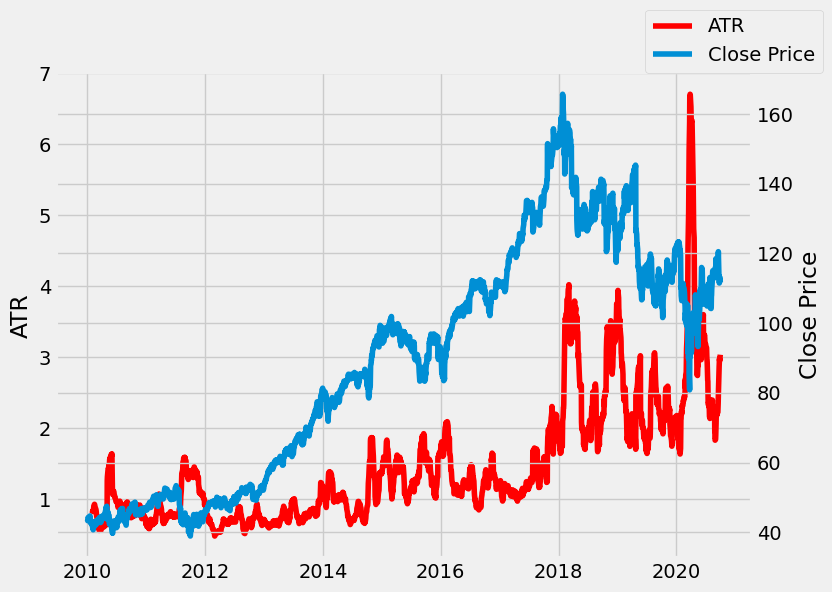

In [10]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax2 = ax1.twinx()

ax1.plot(ohlc['MMM'].ATR, color='red', label='ATR')
ax1.set_ylabel('ATR')
ax2.plot(ohlc['MMM'].Close, label = 'Close Price')
ax2.set_ylabel('Close Price')
fig.legend()

## Daily Stock Price

In [11]:
frames = []

for symbol in dow_stocks:
    close_df = ohlc[symbol]['Close']  # 这是单列 DataFrame
    # 用 rename(columns={旧列名: 新列名}) 改列名
    close_df = close_df.rename(columns={'Close': symbol})
    frames.append(close_df)

stock_price = pd.concat(frames, axis=1)
stock_price.head()

Ticker,MMM,AXP,AMGN,AMZN,AAPL,BA,CAT,CVX,CSCO,KO,DIS,GS,HD,HON,IBM,JNJ,JPM,MCD,MRK,MSFT,NKE,NVDA,PG,CRM,SHW,TRV,UNH,VZ,V,WMT
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-04,43.568951,32.828999,40.265984,6.6950,6.440332,43.777554,39.738232,43.122471,16.363867,17.949802,27.593044,132.649933,20.059742,27.582876,74.269753,41.324886,29.006750,41.265430,21.387213,23.254059,13.509633,0.423923,39.193024,18.601105,17.367304,34.862865,25.203197,14.442017,19.751949,13.084426
2010-01-05,43.296047,32.756802,39.917175,6.7345,6.451465,45.211346,40.213318,43.427917,16.290960,17.732660,27.524216,134.995087,20.206680,27.637566,73.372574,40.845711,29.568613,40.949928,21.473894,23.261560,13.563382,0.430113,39.205845,18.521547,16.956146,34.036972,25.163229,14.468058,19.525623,12.954139
2010-01-06,43.910069,33.286289,39.617203,6.6125,6.348846,46.582802,40.335495,43.433380,16.184916,17.726376,27.377947,133.554321,20.136713,27.637566,72.895958,41.177929,29.731071,40.391243,21.762829,23.118811,13.480689,0.432864,39.019886,18.489231,16.733664,33.554024,25.411024,14.052041,19.263426,12.925181
2010-01-07,43.941555,33.826126,39.254444,6.5000,6.337111,48.468555,40.498371,43.269745,16.257818,17.682314,27.386549,136.167709,20.374601,28.170778,72.643623,40.884041,30.320011,40.687023,21.797501,22.878384,13.612994,0.424381,38.808277,18.407188,16.882919,34.036972,26.386221,13.968395,19.442709,12.932418
2010-01-08,44.251190,33.801979,39.603252,6.6760,6.379241,48.001007,40.953110,43.346104,16.343977,17.355038,27.429569,133.592651,20.276642,28.792841,73.372574,41.024597,30.245546,40.647575,21.785946,23.036161,13.586119,0.425298,38.756977,18.434536,17.026533,33.987984,26.138422,13.977202,19.496492,12.867279


In [12]:
# Check for missing values
stock_price.isnull().sum()

Ticker
MMM     0
AXP     0
AMGN    0
AMZN    0
AAPL    0
BA      0
CAT     0
CVX     0
CSCO    0
KO      0
DIS     0
GS      0
HD      0
HON     0
IBM     0
JNJ     0
JPM     0
MCD     0
MRK     0
MSFT    0
NKE     0
NVDA    0
PG      0
CRM     0
SHW     0
TRV     0
UNH     0
VZ      0
V       0
WMT     0
dtype: int64

In [13]:
# Verify dataframe shape
stock_price.shape

(2704, 30)

<Axes: >

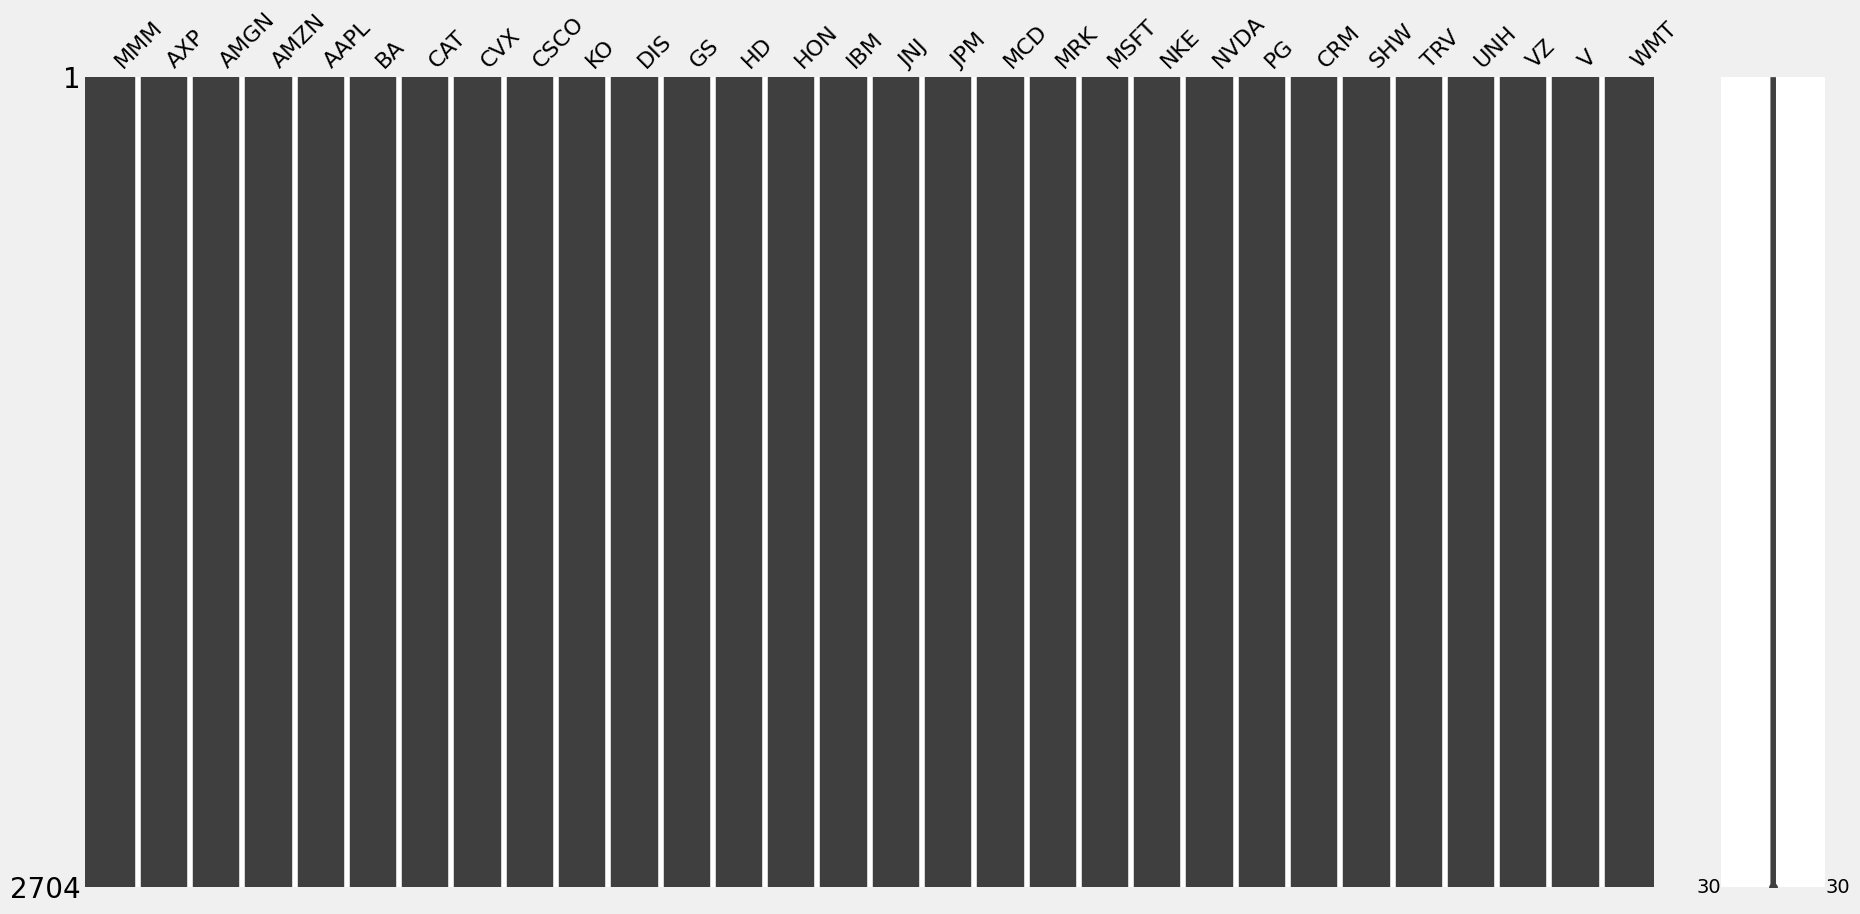

In [14]:
# Alternatively use missingno library to verify missing values
missingno.matrix(stock_price, sparkline=True, figsize=(20,10))

In [15]:
# Get the index of the NaN values
[stock_price[x].index[stock_price[x].apply(np.isnan)] for x in dow_stocks]

[DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex([], dtype='datetime64[ns]', name=

Text(0.5, 1.0, 'MMM Chart')

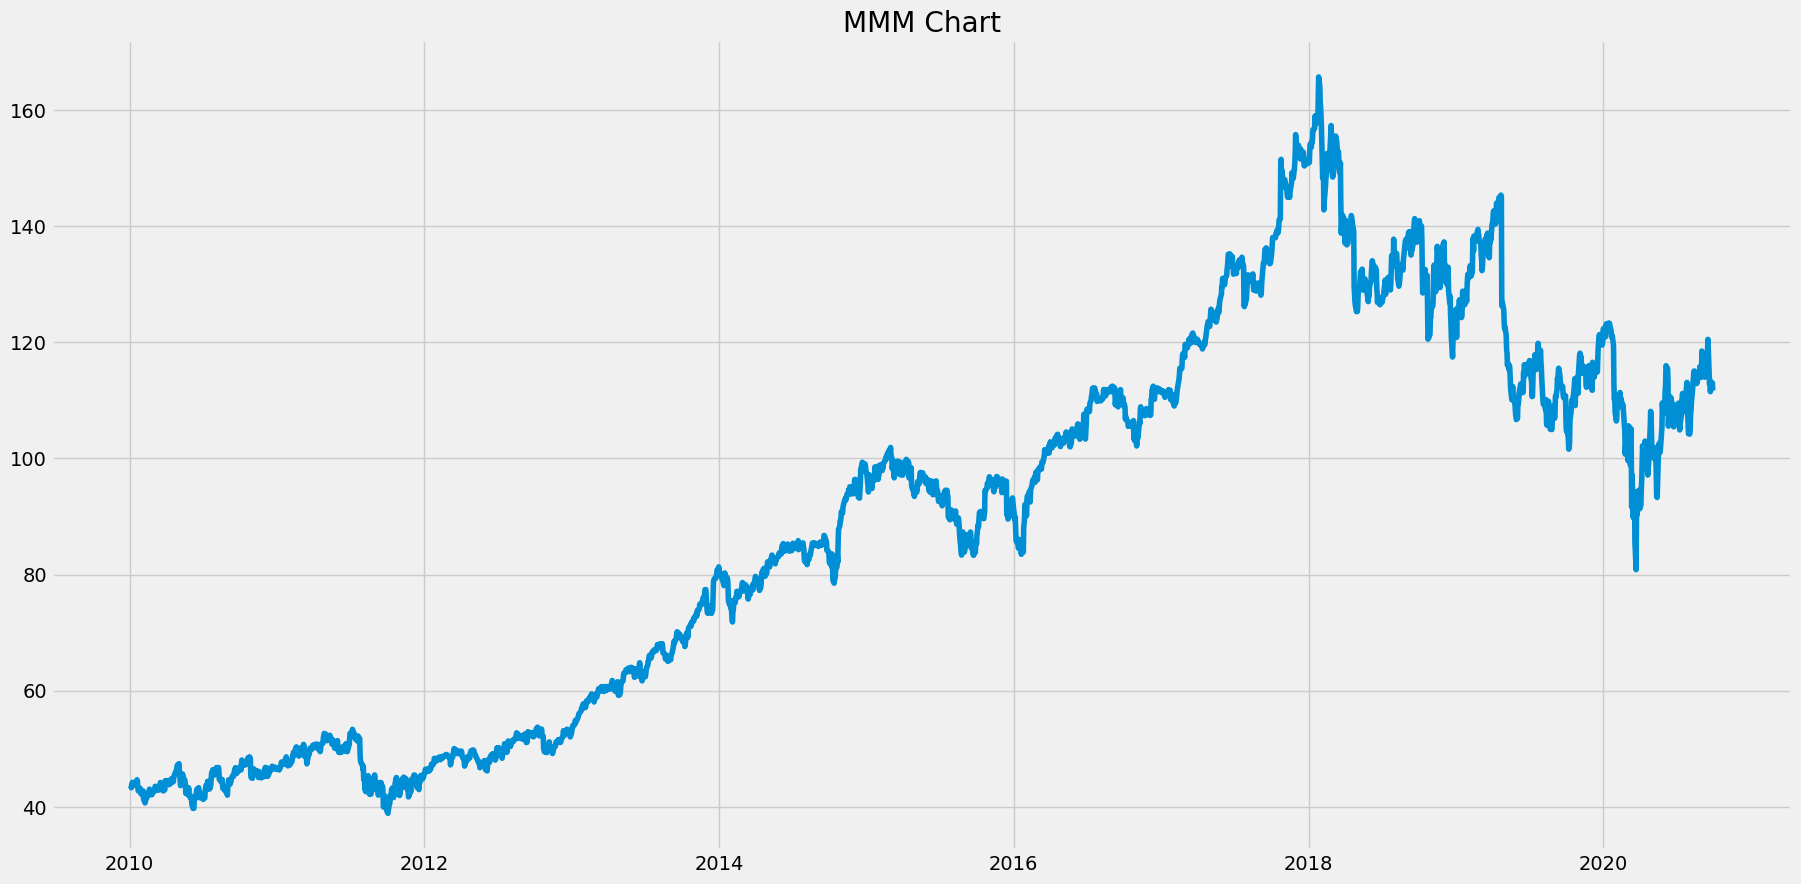

In [16]:
# Plot to verify missing values
plt.figure(figsize=(20,10))
plt.plot(stock_price['MMM'])
plt.title('MMM Chart')

In [17]:
# Fill forward the missing values and drop DOW form the list
stock_price.fillna(method='ffill', axis=0, inplace=True)
stock_price.drop(['MMM'], axis=1, inplace=True)

In [18]:
stock_price.head()

Ticker,AXP,AMGN,AMZN,AAPL,BA,CAT,CVX,CSCO,KO,DIS,GS,HD,HON,IBM,JNJ,JPM,MCD,MRK,MSFT,NKE,NVDA,PG,CRM,SHW,TRV,UNH,VZ,V,WMT
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-04,32.828999,40.265984,6.6950,6.440332,43.777554,39.738232,43.122471,16.363867,17.949802,27.593044,132.649933,20.059742,27.582876,74.269753,41.324886,29.006750,41.265430,21.387213,23.254059,13.509633,0.423923,39.193024,18.601105,17.367304,34.862865,25.203197,14.442017,19.751949,13.084426
2010-01-05,32.756802,39.917175,6.7345,6.451465,45.211346,40.213318,43.427917,16.290960,17.732660,27.524216,134.995087,20.206680,27.637566,73.372574,40.845711,29.568613,40.949928,21.473894,23.261560,13.563382,0.430113,39.205845,18.521547,16.956146,34.036972,25.163229,14.468058,19.525623,12.954139
2010-01-06,33.286289,39.617203,6.6125,6.348846,46.582802,40.335495,43.433380,16.184916,17.726376,27.377947,133.554321,20.136713,27.637566,72.895958,41.177929,29.731071,40.391243,21.762829,23.118811,13.480689,0.432864,39.019886,18.489231,16.733664,33.554024,25.411024,14.052041,19.263426,12.925181
2010-01-07,33.826126,39.254444,6.5000,6.337111,48.468555,40.498371,43.269745,16.257818,17.682314,27.386549,136.167709,20.374601,28.170778,72.643623,40.884041,30.320011,40.687023,21.797501,22.878384,13.612994,0.424381,38.808277,18.407188,16.882919,34.036972,26.386221,13.968395,19.442709,12.932418
2010-01-08,33.801979,39.603252,6.6760,6.379241,48.001007,40.953110,43.346104,16.343977,17.355038,27.429569,133.592651,20.276642,28.792841,73.372574,41.024597,30.245546,40.647575,21.785946,23.036161,13.586119,0.425298,38.756977,18.434536,17.026533,33.987984,26.138422,13.977202,19.496492,12.867279


In [19]:
# Verify whether missing values are dropped
np.isnan(stock_price.any()).sum()

0

## Weekly Stock Price

In [20]:
# Manipulate stock price dataframe: drop and resample
weekly_stock_price = stock_price.resample('W-FRI').last().pct_change()
weekly_stock_price = weekly_stock_price.T

# Check output
weekly_stock_price

Date,2010-01-08,2010-01-15,2010-01-22,2010-01-29,2010-02-05,2010-02-12,2010-02-19,2010-02-26,2010-03-05,2010-03-12,2010-03-19,2010-03-26,2010-04-02,2010-04-09,2010-04-16,2010-04-23,2010-04-30,2010-05-07,2010-05-14,2010-05-21,2010-05-28,2010-06-04,2010-06-11,2010-06-18,2010-06-25,2010-07-02,2010-07-09,2010-07-16,2010-07-23,2010-07-30,2010-08-06,2010-08-13,2010-08-20,2010-08-27,2010-09-03,2010-09-10,2010-09-17,2010-09-24,2010-10-01,2010-10-08,2010-10-15,2010-10-22,2010-10-29,2010-11-05,2010-11-12,2010-11-19,2010-11-26,2010-12-03,2010-12-10,2010-12-17,2010-12-24,2010-12-31,2011-01-07,2011-01-14,2011-01-21,2011-01-28,2011-02-04,2011-02-11,2011-02-18,2011-02-25,2011-03-04,2011-03-11,2011-03-18,2011-03-25,2011-04-01,2011-04-08,2011-04-15,2011-04-22,2011-04-29,2011-05-06,2011-05-13,2011-05-20,2011-05-27,2011-06-03,2011-06-10,2011-06-17,2011-06-24,2011-07-01,2011-07-08,2011-07-15,2011-07-22,2011-07-29,2011-08-05,2011-08-12,2011-08-19,2011-08-26,2011-09-02,2011-09-09,2011-09-16,2011-09-23,2011-09-30,2011-10-07,2011-10-14,2011-10-21,2011-10-28,2011-11-04,2011-11-11,2011-11-18,2011-11-25,2011-12-02,2011-12-09,2011-12-16,2011-12-23,2011-12-30,2012-01-06,2012-01-13,2012-01-20,2012-01-27,2012-02-03,2012-02-10,2012-02-17,2012-02-24,2012-03-02,2012-03-09,2012-03-16,2012-03-23,2012-03-30,2012-04-06,2012-04-13,2012-04-20,2012-04-27,2012-05-04,2012-05-11,2012-05-18,2012-05-25,2012-06-01,2012-06-08,2012-06-15,2012-06-22,2012-06-29,2012-07-06,2012-07-13,2012-07-20,2012-07-27,2012-08-03,2012-08-10,2012-08-17,2012-08-24,2012-08-31,2012-09-07,2012-09-14,2012-09-21,2012-09-28,2012-10-05,2012-10-12,2012-10-19,2012-10-26,2012-11-02,2012-11-09,2012-11-16,2012-11-23,2012-11-30,2012-12-07,2012-12-14,2012-12-21,2012-12-28,2013-01-04,2013-01-11,2013-01-18,2013-01-25,2013-02-01,2013-02-08,2013-02-15,2013-02-22,2013-03-01,2013-03-08,2013-03-15,2013-03-22,2013-03-29,2013-04-05,2013-04-12,2013-04-19,2013-04-26,2013-05-03,2013-05-10,2013-05-17,2013-05-24,2013-05-31,2013-06-07,2013-06-14,2013-06-21,2013-06-28,2013-07-05,2013-07-12,2013-07-19,2013-07-26,2013-08-02,2013-08-09,2013-08-16,2013-08-23,2013-08-30,2013-09-06,2013-09-13,2013-09-20,2013-09-27,2013-10-04,2013-10-11,2013-10-18,2013-10-25,2013-11-01,2013-11-08,2013-11-15,2013-11-22,2013-11-29,2013-12-06,2013-12-13,2013-12-20,2013-12-27,2014-01-03,2014-01-10,2014-01-17,2014-01-24,2014-01-31,2014-02-07,2014-02-14,2014-02-21,2014-02-28,2014-03-07,2014-03-14,2014-03-21,2014-03-28,2014-04-04,2014-04-11,2014-04-18,2014-04-25,2014-05-02,2014-05-09,2014-05-16,2014-05-23,2014-05-30,2014-06-06,2014-06-13,2014-06-20,2014-06-27,2014-07-04,2014-07-11,2014-07-18,2014-07-25,2014-08-01,2014-08-08,2014-08-15,2014-08-22,2014-08-29,2014-09-05,2014-09-12,2014-09-19,2014-09-26,2014-10-03,2014-10-10,2014-10-17,2014-10-24,2014-10-31,2014-11-07,2014-11-14,2014-11-21,2014-11-28,2014-12-05,2014-12-12,2014-12-19,2014-12-26,2015-01-02,2015-01-09,2015-01-16,2015-01-23,2015-01-30,2015-02-06,2015-02-13,2015-02-20,2015-02-27,2015-03-06,2015-03-13,2015-03-20,2015-03-27,2015-04-03,2015-04-10,2015-04-17,2015-04-24,2015-05-01,2015-05-08,2015-05-15,2015-05-22,2015-05-29,2015-06-05,2015-06-12,2015-06-19,2015-06-26,2015-07-03,2015-07-10,2015-07-17,2015-07-24,2015-07-31,2015-08-07,2015-08-14,2015-08-21,2015-08-28,2015-09-04,2015-09-11,2015-09-18,2015-09-25,2015-10-02,2015-10-09,2015-10-16,2015-10-23,2015-10-30,2015-11-06,2015-11-13,2015-11-20,2015-11-27,2015-12-04,2015-12-11,2015-12-18,2015-12-25,2016-01-01,2016-01-08,2016-01-15,2016-01-22,2016-01-29,2016-02-05,2016-02-12,2016-02-19,2016-02-26,2016-03-04,2016-03-11,2016-03-18,2016-03-25,2016-04-01,2016-04-08,2016-04-15,2016-04-22,2016-04-29,2016-05-06,2016-05-13,2016-05-20,2016-05-27,2016-06-03,2016-06-10,2016-06-17,2016-06-24,2016-07-01,2016-07-08,2016-07-15,2016-07-22,2016-07-29,2016-08-05,2016-08-12,2016-08-19,2016-08-26,2016-09-02,2016-09-09,2016-09-16,2016-09-23,2016-09-30,2016-10-07,2016-10-14,2016-10-21,2016-10-28,2016-11-04,2016-11-11,2016-11-18,2016-11-25,2016-12-02,2016-12-09,2016-12-16,20

## Daily Stock ATR

In [21]:
# Add ATR to each stocks
stock_atr = pd.DataFrame({symbol: ohlc[symbol]['ATR'] for symbol in dow_stocks})

In [22]:
# Check for missing values
stock_atr.isnull().sum()

MMM     21
AXP     21
AMGN    21
AMZN    21
AAPL    21
BA      21
CAT     21
CVX     21
CSCO    21
KO      21
DIS     21
GS      21
HD      21
HON     21
IBM     21
JNJ     21
JPM     21
MCD     21
MRK     21
MSFT    21
NKE     21
NVDA    21
PG      21
CRM     21
SHW     21
TRV     21
UNH     21
VZ      21
V       21
WMT     21
dtype: int64

In [23]:
# Fill backward the missing values and drop DOW form the list
stock_atr.fillna(method='bfill', axis=0, inplace=True)
stock_atr.drop(['MMM'], axis=1, inplace=True)

In [24]:
# Verify dataframe shape
stock_atr.shape

(2704, 29)

## Weekly ATR

In [25]:
# Manipulate dataframe: drop and resample
weekly_atr = stock_atr.resample('W-FRI').last()
weekly_atr = weekly_atr.T

# Check output
weekly_atr.head()

Date,2010-01-08,2010-01-15,2010-01-22,2010-01-29,2010-02-05,2010-02-12,2010-02-19,2010-02-26,2010-03-05,2010-03-12,2010-03-19,2010-03-26,2010-04-02,2010-04-09,2010-04-16,2010-04-23,2010-04-30,2010-05-07,2010-05-14,2010-05-21,2010-05-28,2010-06-04,2010-06-11,2010-06-18,2010-06-25,2010-07-02,2010-07-09,2010-07-16,2010-07-23,2010-07-30,2010-08-06,2010-08-13,2010-08-20,2010-08-27,2010-09-03,2010-09-10,2010-09-17,2010-09-24,2010-10-01,2010-10-08,2010-10-15,2010-10-22,2010-10-29,2010-11-05,2010-11-12,2010-11-19,2010-11-26,2010-12-03,2010-12-10,2010-12-17,2010-12-24,2010-12-31,2011-01-07,2011-01-14,2011-01-21,2011-01-28,2011-02-04,2011-02-11,2011-02-18,2011-02-25,2011-03-04,2011-03-11,2011-03-18,2011-03-25,2011-04-01,2011-04-08,2011-04-15,2011-04-22,2011-04-29,2011-05-06,2011-05-13,2011-05-20,2011-05-27,2011-06-03,2011-06-10,2011-06-17,2011-06-24,2011-07-01,2011-07-08,2011-07-15,2011-07-22,2011-07-29,2011-08-05,2011-08-12,2011-08-19,2011-08-26,2011-09-02,2011-09-09,2011-09-16,2011-09-23,2011-09-30,2011-10-07,2011-10-14,2011-10-21,2011-10-28,2011-11-04,2011-11-11,2011-11-18,2011-11-25,2011-12-02,2011-12-09,2011-12-16,2011-12-23,2011-12-30,2012-01-06,2012-01-13,2012-01-20,2012-01-27,2012-02-03,2012-02-10,2012-02-17,2012-02-24,2012-03-02,2012-03-09,2012-03-16,2012-03-23,2012-03-30,2012-04-06,2012-04-13,2012-04-20,2012-04-27,2012-05-04,2012-05-11,2012-05-18,2012-05-25,2012-06-01,2012-06-08,2012-06-15,2012-06-22,2012-06-29,2012-07-06,2012-07-13,2012-07-20,2012-07-27,2012-08-03,2012-08-10,2012-08-17,2012-08-24,2012-08-31,2012-09-07,2012-09-14,2012-09-21,2012-09-28,2012-10-05,2012-10-12,2012-10-19,2012-10-26,2012-11-02,2012-11-09,2012-11-16,2012-11-23,2012-11-30,2012-12-07,2012-12-14,2012-12-21,2012-12-28,2013-01-04,2013-01-11,2013-01-18,2013-01-25,2013-02-01,2013-02-08,2013-02-15,2013-02-22,2013-03-01,2013-03-08,2013-03-15,2013-03-22,2013-03-29,2013-04-05,2013-04-12,2013-04-19,2013-04-26,2013-05-03,2013-05-10,2013-05-17,2013-05-24,2013-05-31,2013-06-07,2013-06-14,2013-06-21,2013-06-28,2013-07-05,2013-07-12,2013-07-19,2013-07-26,2013-08-02,2013-08-09,2013-08-16,2013-08-23,2013-08-30,2013-09-06,2013-09-13,2013-09-20,2013-09-27,2013-10-04,2013-10-11,2013-10-18,2013-10-25,2013-11-01,2013-11-08,2013-11-15,2013-11-22,2013-11-29,2013-12-06,2013-12-13,2013-12-20,2013-12-27,2014-01-03,2014-01-10,2014-01-17,2014-01-24,2014-01-31,2014-02-07,2014-02-14,2014-02-21,2014-02-28,2014-03-07,2014-03-14,2014-03-21,2014-03-28,2014-04-04,2014-04-11,2014-04-18,2014-04-25,2014-05-02,2014-05-09,2014-05-16,2014-05-23,2014-05-30,2014-06-06,2014-06-13,2014-06-20,2014-06-27,2014-07-04,2014-07-11,2014-07-18,2014-07-25,2014-08-01,2014-08-08,2014-08-15,2014-08-22,2014-08-29,2014-09-05,2014-09-12,2014-09-19,2014-09-26,2014-10-03,2014-10-10,2014-10-17,2014-10-24,2014-10-31,2014-11-07,2014-11-14,2014-11-21,2014-11-28,2014-12-05,2014-12-12,2014-12-19,2014-12-26,2015-01-02,2015-01-09,2015-01-16,2015-01-23,2015-01-30,2015-02-06,2015-02-13,2015-02-20,2015-02-27,2015-03-06,2015-03-13,2015-03-20,2015-03-27,2015-04-03,2015-04-10,2015-04-17,2015-04-24,2015-05-01,2015-05-08,2015-05-15,2015-05-22,2015-05-29,2015-06-05,2015-06-12,2015-06-19,2015-06-26,2015-07-03,2015-07-10,2015-07-17,2015-07-24,2015-07-31,2015-08-07,2015-08-14,2015-08-21,2015-08-28,2015-09-04,2015-09-11,2015-09-18,2015-09-25,2015-10-02,2015-10-09,2015-10-16,2015-10-23,2015-10-30,2015-11-06,2015-11-13,2015-11-20,2015-11-27,2015-12-04,2015-12-11,2015-12-18,2015-12-25,2016-01-01,2016-01-08,2016-01-15,2016-01-22,2016-01-29,2016-02-05,2016-02-12,2016-02-19,2016-02-26,2016-03-04,2016-03-11,2016-03-18,2016-03-25,2016-04-01,2016-04-08,2016-04-15,2016-04-22,2016-04-29,2016-05-06,2016-05-13,2016-05-20,2016-05-27,2016-06-03,2016-06-10,2016-06-17,2016-06-24,2016-07-01,2016-07-08,2016-07-15,2016-07-22,2016-07-29,2016-08-05,2016-08-12,2016-08-19,2016-08-26,2016-09-02,2016-09-09,2016-09-16,2016-09-23,2016-09-30,2016-10-07,2016-10-14,2016-10-21,2016-10-28,2016-11-04,2016-11-11,2016-11-18,2016-11-25,2016-12-02,2016-12-09,2016-12-16,20

<Axes: xlabel='Date'>

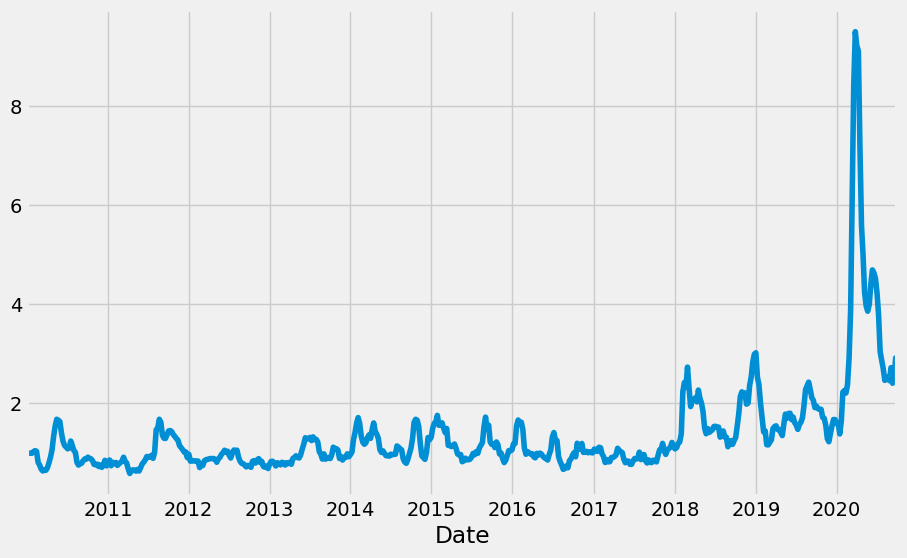

In [26]:
# Plot weekly atr values
weekly_atr.iloc[0,:].plot()

In [27]:
# Summary statistics
weekly_atr.T.describe()

,AXP,AMGN,AMZN,AAPL,BA,CAT,CVX,CSCO,KO,DIS,GS,HD,HON,IBM,JNJ,JPM,MCD,MRK,MSFT,NKE,NVDA,PG,CRM,SHW,TRV,UNH,VZ,V,WMT
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,1.348187,2.323650,0.983712,0.666923,3.793542,1.914739,1.347047,0.477384,0.436667,1.468922,3.260470,1.795933,1.477021,1.649797,1.153133,1.174101,1.494226,0.725919,1.249741,0.936922,0.080804,0.925469,2.197149,1.683711,1.303359,2.591464,0.467064,1.474573,0.352216
std,0.993741,1.571969,1.138007,0.760989,3.846398,1.072866,0.682865,0.321444,0.287968,1.050833,1.433121,1.811424,1.228980,0.623547,0.831909,0.893762,1.342357,0.444946,1.484696,0.785715,0.116854,0.709240,1.854057,1.599657,0.908894,2.693112,0.236714,1.557809,0.257179
min,0.572620,0.493642,0.149333,0.095325,0.752613,0.673192,0.506346,0.170742,0.180221,0.418312,1.491520,0.302410,0.459303,0.747534,0.329983,0.476804,0.442336,0.242703,0.269392,0.205970,0.005373,0.360837,0.385821,0.253183,0.442713,0.496167,0.138566,0.248007,0.123266
25%,0.867029,1.016890,0.299119,0.295175,1.374941,1.219572,0.944780,0.284677,0.299449,0.798698,2.338669,0.719844,0.798304,1.258188,0.642244,0.679604,0.766067,0.447274,0.478271,0.443510,0.010634,0.583293,1.156635,0.707621,0.743146,0.945532,0.326678,0.577680,0.214505
50%,1.046289,2.140086,0.506619,0.427910,2.075593,1.526184,1.161109,0.356837,0.366994,1.196050,2.964683,1.313662,1.117401,1.508221,0.930483,0.898265,1.087036,0.615193,0.713152,0.727325,0.018230,0.746148,1.512031,1.247613,1.056223,1.704117,0.422877,0.964680,0.278933
75%,1.466801,2.893725,1.138190,0.679789,5.818122,2.237542,1.578026,0.586117,0.474735,1.802570,3.674550,2.339694,1.642422,1.856910,1.397428,1.353015,1.802021,0.858477,1.316010,1.209767,0.128561,0.975206,2.584138,2.095944,1.550560,3.174527,0.542869,1.762655,0.390833
max,9.494130,12.146153,6.218145,5.921635,25.925239,7.978704,6.510608,2.581961,2.992685,8.951324,13.618577,15.990888,11.614472,6.270269,7.154969,8.356952,13.177898,3.863893,11.173007,6.839977,0.742447,7.254352,12.955258,13.584191,8.327082,22.198630,2.437032,12.883217,2.356878


## Elbow Plot

The number of clusters is a hyperparameter to clustering models and choose the optimal number of clusters is critical for the model. If every point is its own cluster, the inertia is zero and hence choosing the number of clusters that yields the lowest results in not appropriate. Instead, we need to identify the **inflection point** where increasing the number of clusters no longer result in significant drop in inertia. Elbow plot helps us to select the optimal number of clusters.

In [28]:
# Import sklearn modules
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# import yfinance as yf
from datetime import datetime

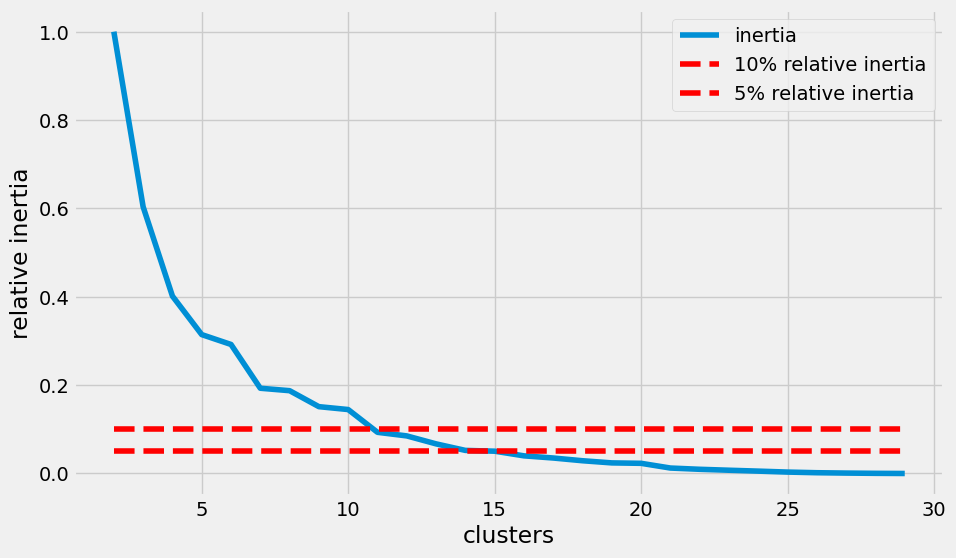

In [29]:
n_clusters = range(2, 30)
inertia = []

for n in n_clusters:
    kmeans = KMeans(n_clusters=n)
    kmeans.fit(weekly_atr)
    inertia.append(kmeans.inertia_)
    
plt.plot(n_clusters, np.divide(inertia,inertia[0]))
plt.hlines(0.1, n_clusters[0], n_clusters[-1], 'r', linestyles='dashed')
plt.hlines(0.05, n_clusters[0], n_clusters[-1], 'r', linestyles='dashed')
plt.xlabel('clusters')
plt.ylabel('relative inertia')
plt.legend(['inertia', '10% relative inertia', '5% relative inertia'])

Silhouette Coefficient is another metric measure of how dense and separated are the clusters. Silhouette coefficient values range between -1 and 1. Larger numbers indicate that samples are closer to their clusters than they are to other clusters. Silhouette coefficient implementation is straight forward where the average silhouette coefficient of all the samples is summarized into one score. The `silhouette_score` function needs a minimum of two clusters, or it will raise an exception.

## Build Clusters

We will now fit the cluster model. Given the timeseries characteristics, the dataset needs to be normalized for the model to work properly. The normalizing can be accomplished by using the `Normalizer` transformer from `Scikit-Learn`.

In [30]:
# Normalize and fit the model
pipe = Pipeline([("normalization", MinMaxScaler()), ("cluster", KMeans(n_clusters=15))])

In [31]:
# Fit Model
pipe.fit(weekly_atr)
# Assign Label
labels = pipe.predict(weekly_atr)

In [32]:
# Check lables
labels

array([ 2,  1, 12,  0,  5,  7, 10,  0,  0, 14,  4,  9, 14, 11,  3,  3, 14,
        0, 12,  3, 13,  3,  6,  9, 14,  8,  0, 14,  0])

In [33]:
# Check average weekly stock price
weekly_stock_price.mean(axis=1)

Ticker
AXP     0.002550
AMGN    0.003558
AMZN    0.006506
AAPL    0.005884
BA      0.003798
CAT     0.002933
CVX     0.001156
CSCO    0.001927
KO      0.001935
DIS     0.003209
GS      0.001295
HD      0.005020
HON     0.003483
IBM     0.000911
JNJ     0.002290
JPM     0.002521
MCD     0.003115
MRK     0.002408
MSFT    0.004346
NKE     0.004472
NVDA    0.007740
PG      0.002302
CRM     0.005698
SHW     0.005131
TRV     0.002309
UNH     0.004904
VZ      0.002389
V       0.004592
WMT     0.002466
dtype: float64

In [34]:
# Remove DOW from the list
companies = dow_stocks
companies.remove('MMM')

# Remove Dow Inc from the compnay name
companies_name = dow_company_name
companies_name.remove('3M')

In [35]:
# Create dataframe to hold cluster details
df = pd.DataFrame({'Cluster': labels,
                   'Companies Name': companies_name,
                   'Companies': companies,
                   'ATR': weekly_atr.mean(axis=1),
                   'CHG': weekly_stock_price.mean(axis=1)}
                 ).sort_values(by=['Cluster'], axis = 0)

df = df.reset_index(drop=True)
df

,Cluster,Companies Name,Companies,ATR,CHG
0,0,Walmart,WMT,0.352216,0.002466
1,0,Verizon,VZ,0.467064,0.002389
2,0,Apple,AAPL,0.666923,0.005884
3,0,Merck,MRK,0.725919,0.002408
4,0,Coca-Cola,KO,0.436667,0.001935
5,0,Cisco,CSCO,0.477384,0.001927
6,1,Amgen,AMGN,2.323650,0.003558
7,2,American Express,AXP,1.348187,0.002550
8,3,Johnson & Johnson,JNJ,1.153133,0.002290
9,3,Procter & Gamble,PG,0.925469,0.002302


Thus, using k-means, we have discovered companies that exhibit similar volatility characteristics as measured by the Average True Range (ATR).

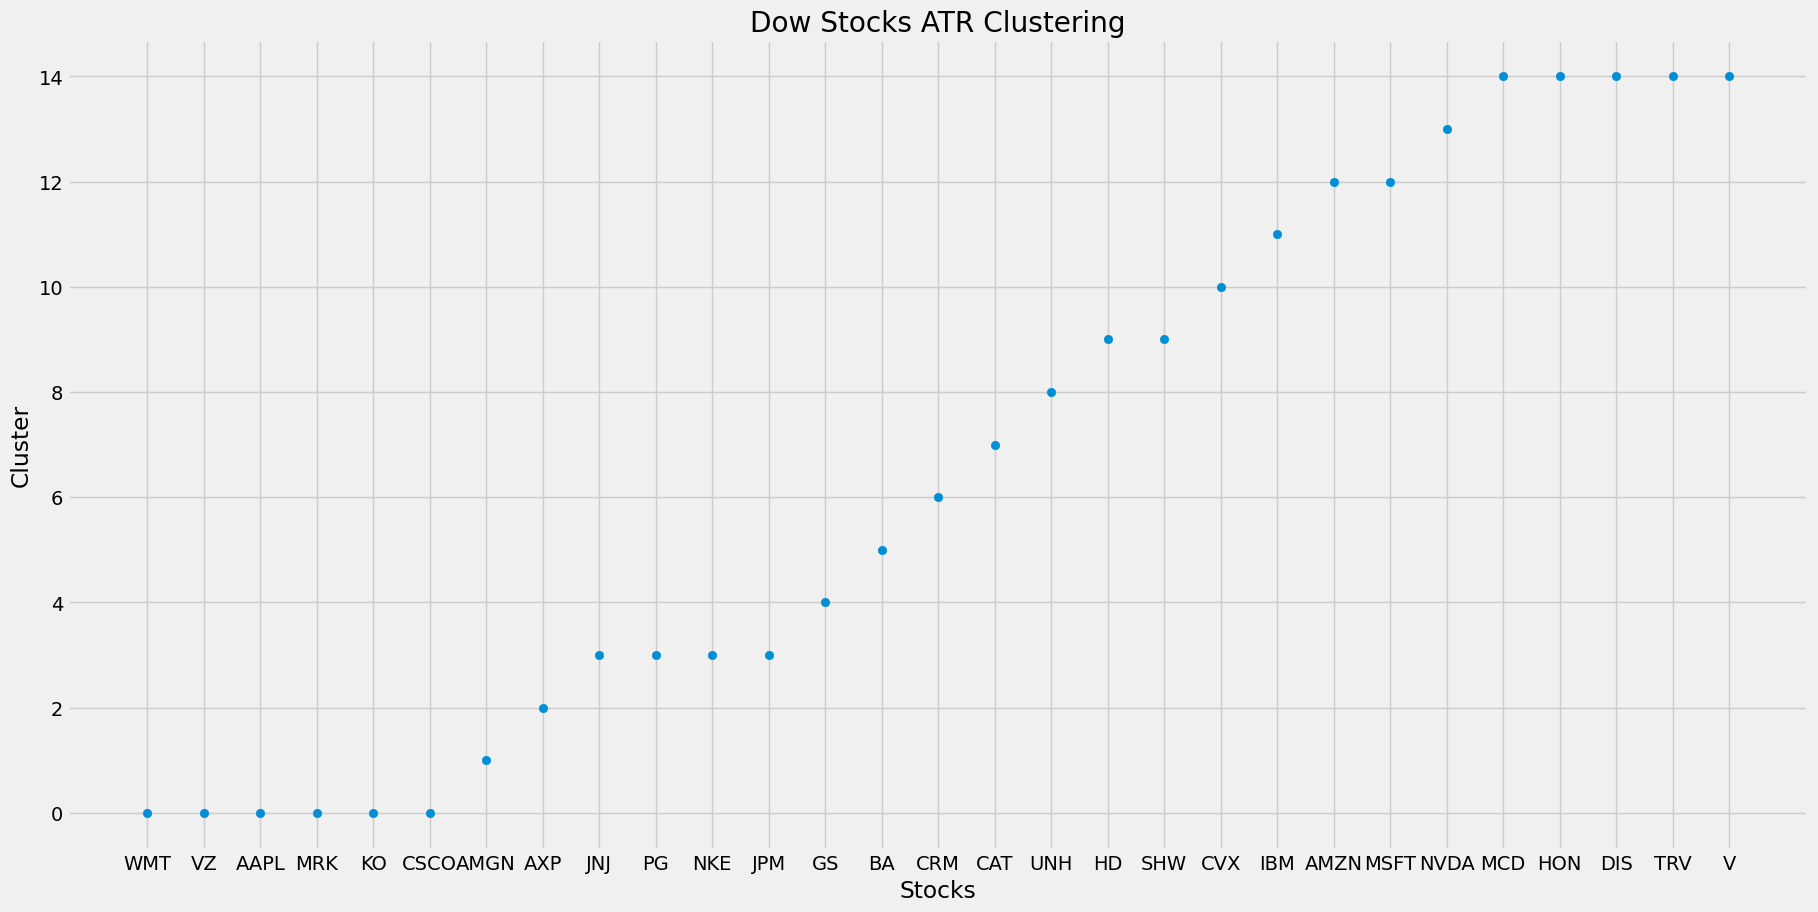

In [36]:
plt.figure(figsize=(20,10))
plt.scatter(df.Companies, df.Cluster)
plt.xlabel('Stocks')
plt.ylabel('Cluster')
plt.title('Dow Stocks ATR Clustering');

In [37]:
pipe.get_params()

{'memory': None,
 'steps': [('normalization', MinMaxScaler()),
  ('cluster', KMeans(n_clusters=15))],
 'transform_input': None,
 'verbose': False,
 'normalization': MinMaxScaler(),
 'cluster': KMeans(n_clusters=15),
 'normalization__clip': False,
 'normalization__copy': True,
 'normalization__feature_range': (0, 1),
 'cluster__algorithm': 'lloyd',
 'cluster__copy_x': True,
 'cluster__init': 'k-means++',
 'cluster__max_iter': 300,
 'cluster__n_clusters': 15,
 'cluster__n_init': 'auto',
 'cluster__random_state': None,
 'cluster__tol': 0.0001,
 'cluster__verbose': 0}

In [38]:
pipe['cluster'].cluster_centers_

array([[0.07956559, 0.07956559, 0.07956559, ..., 0.09038352, 0.11433017,
        0.12091744],
       [0.20284495, 0.20284495, 0.20284495, ..., 0.42069197, 0.51481305,
        0.53869799],
       [0.25134387, 0.25134387, 0.25134387, ..., 0.15444847, 0.21553667,
        0.23186021],
       ...,
       [0.09876578, 0.09876578, 0.09876578, ..., 0.46390917, 0.59549688,
        0.62767956],
       [0.        , 0.        , 0.        , ..., 0.00654583, 0.00454864,
        0.00488967],
       [0.1538447 , 0.1538447 , 0.1538447 , ..., 0.22994183, 0.31064195,
        0.33081184]])

In [39]:
pipe['cluster'].cluster_centers_.shape

(15, 561)

In [40]:
# Save locally to be used in SOM
df.to_csv('cluster_new.csv')

# Trading Strategy

For this exercise, we'll use HDFCBANK to identify three clusters based on scaled volumed & range and measure the performance of these clusters.

## Retrive Data

In [41]:
# Retrieve data from yahoo finance if you do no have the data stored in local drive
hdfcbank = yf.download('HDFCBANK.NS', auto_adjust=True)
hdfcbank.to_csv('hdfcbank.csv')

df1 = pd.read_csv('hdfcbank.csv', index_col=0, parse_dates=True)[2000:]
# Check last 5 values
df1.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Price,,,,,
2003-08-28,23.967681884765625,24.407182958614396,23.7244635866473,24.407182958614396,3796790
2003-08-29,23.52817726135254,23.94207571831763,23.216687257352522,23.383099569159516,3715070
2003-09-01,23.762863159179688,23.895140415317726,23.46844147932991,23.46844147932991,1314860
2003-09-02,24.061553955078125,24.663199420096277,23.468442664537996,23.468442664537996,1198770
2003-09-03,23.92500877380371,24.833877946627556,23.89513997904808,23.89513997904808,4867130


In [50]:
# Plot share price
plt.title('HDFCBANK Share Price')
plt.plot(df1['Close'])
plt.show()


KeyboardInterrupt



In [51]:
# 复制数据
df2 = df1.copy(deep=True)

# 先将用于计算的列转换为数值类型
cols = ['High', 'Low', 'Close', 'Volume']
df2[cols] = df2[cols].apply(pd.to_numeric, errors='coerce')

# 计算 ATR、scaled volume 和 range
df2['ATR'] = ATR(df2, 20)
df2['Svolume'] = df2['Volume'] / df2['Volume'].rolling(20).mean()
df2['Range'] = (df2['High'] - df2['Low']) / df2['ATR']

# 在计算 Return 前，确保 Open 列也是数值类型
df2['Open'] = pd.to_numeric(df2['Open'], errors='coerce')
df2['Return'] = df2['Open'].shift(-2) - df2['Open'].shift(-1)
df2['Target'] = 0

# 删除 NaN 值
df2.dropna(inplace=True)

# 查看最后5行
df2.tail()

,Close,High,Low,Open,Volume,ATR,Svolume,Range,Return,Target
Price,,,,,,,,,,
2025-02-27,1700.699951,1710.750000,1682.550049,1682.550049,17893400,28.795001,1.774236,0.979335,54.800049,0
2025-02-28,1732.400024,1737.250000,1685.000000,1685.000000,27258364,30.370001,2.466261,1.720448,-41.800049,0
2025-03-03,1701.550049,1743.050049,1694.099976,1739.800049,10602682,30.970007,0.926569,1.580564,3.949951,0
2025-03-04,1710.000000,1714.300049,1693.250000,1698.000000,9960479,30.647510,0.871123,0.686844,-14.949951,0
2025-03-05,1690.000000,1710.800049,1688.250000,1701.949951,10791936,29.385010,0.958581,0.767400,-5.000000,0


In [52]:
# Summary statistics
df2.describe()

,Close,High,Low,Open,Volume,ATR,Svolume,Range,Return,Target
count,5312.000000,5312.000000,5312.000000,5312.000000,5.312000e+03,5312.000000,5312.000000,5312.000000,5312.000000,5312.0
mean,610.127161,615.939102,604.077761,610.193895,7.720183e+06,12.578903,1.012250,0.965575,0.312335,0.0
std,555.933153,560.527794,551.348617,556.018809,8.476684e+06,11.578661,0.592940,0.468064,12.661075,0.0
min,22.858263,23.212421,22.061658,22.657708,0.000000e+00,0.626795,0.000000,0.000000,-132.477044,0.0
25%,126.866268,129.249211,123.665912,126.845955,3.275620e+06,4.288251,0.678093,0.680209,-2.744729,0.0
50%,371.993057,377.152047,367.194364,372.497552,5.527558e+06,7.856667,0.899331,0.874618,0.094922,0.0
75%,1069.788116,1080.072011,1058.958334,1070.188485,9.443696e+06,19.578260,1.195312,1.139936,3.365582,0.0
max,1871.750000,1880.000000,1858.550049,1877.699951,2.226710e+08,83.102931,15.269140,7.599543,145.484789,0.0


## Split Data

In [53]:
# Split the data from 2015
df2.index = pd.to_datetime(df2.index)

df_train = df2[df2.index <= datetime(2019, 1, 1)]
df_test  = df2[df2.index > datetime(2019, 1, 1)]

## Specify Features

In [54]:
# Define train and test with two features
X_train = df_train[['Svolume', 'Range']]
X_test = df_test[['Svolume', 'Range']]

## Model Training

In [55]:
# Training with 3 clusters
kmeans = KMeans(n_clusters=3).fit(X_train)
df_train['Target'] = kmeans.predict(X_train)

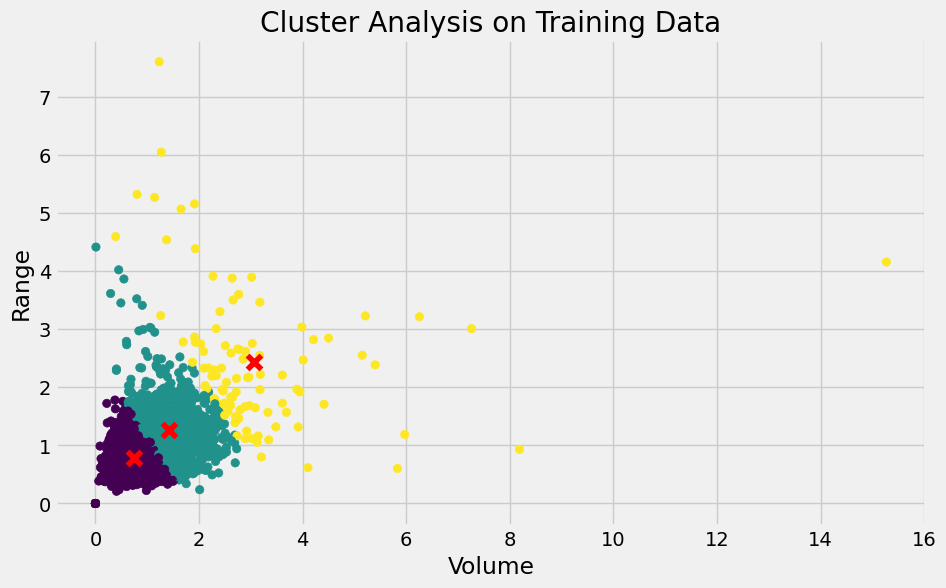

In [56]:
# Train plot
centers = kmeans.cluster_centers_
plt.scatter(X_train['Svolume'], X_train['Range'], c=df_train['Target'])
plt.scatter(centers[:,0], centers[:,1], c='red', s=100, marker='x')
plt.xlabel('Volume')
plt.ylabel('Range')
plt.title('Cluster Analysis on Training Data')
plt.show()

In [57]:
# Centroid for first feature
centers[:,0]

array([0.74748341, 1.41375901, 3.05921404])

In [58]:
# Centroid for second feature
centers[:,1]

array([0.78984807, 1.2589608 , 2.42851891])

## Testing

In [59]:
# Testing : Assign to df_train dataframe
df_test['Target'] = kmeans.predict(X_test)

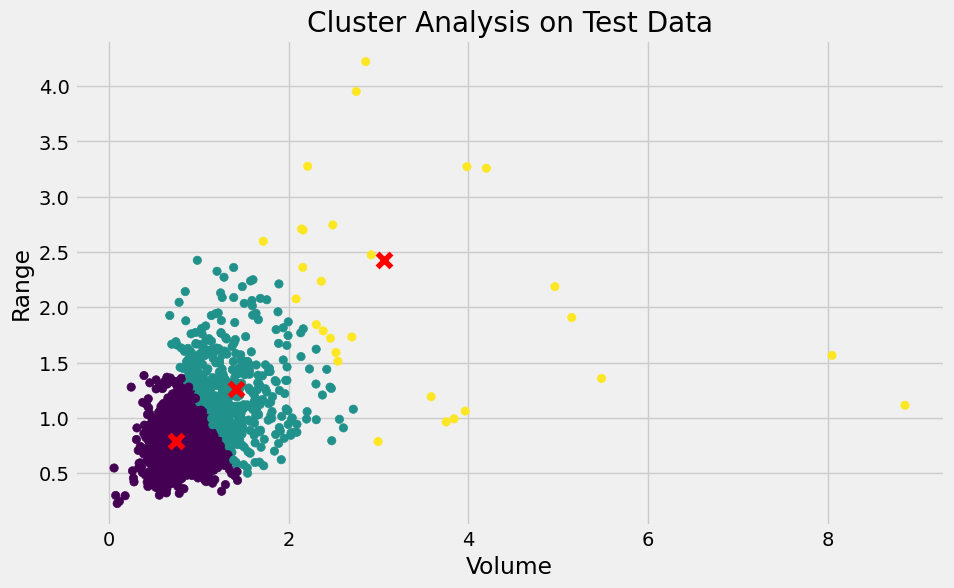

In [60]:
# Test plot
centers = kmeans.cluster_centers_
plt.scatter(X_test['Svolume'], X_test['Range'], c=df_test['Target'])
plt.scatter(centers[:,0],centers[:,1], c='red', s=100, marker='x')
plt.xlabel('Volume')
plt.ylabel('Range')
plt.title('Cluster Analysis on Test Data')
plt.show()

In [61]:
# Centroid for first feature
centers[:,0]

array([0.74748341, 1.41375901, 3.05921404])

In [62]:
# Centroid for second feature
centers[:,1]

array([0.78984807, 1.2589608 , 2.42851891])

We can see there are three distinct clusters and there is a clear relationship between higher volume and higher volatility (range). These clusters and centroids appear relatively stable in our test data set.

In [63]:
# Output the results
print("Total Points Earned by Cluster Prediction: Training & Testing")

print(f"Cluster 1 Train: {df_train.Return.loc[df_train.Target == 0].sum():0.4f}"
      f"\t Cluster 1 Test: {df_test.Return.loc[df_test.Target == 0].sum():0.4f}")

print(f"Cluster 2 Train: {df_train.Return.loc[df_train.Target == 1].sum():0.4f}"
      f"\t Cluster 2 Test: {df_test.Return.loc[df_test.Target == 1].sum():0.4f}")

print(f"Cluster 3 Train: {df_train.Return.loc[df_train.Target == 2].sum():0.4f}"
      f"\t Cluster 3 Test: {df_test.Return.loc[df_test.Target == 2].sum():0.4f}")

Total Points Earned by Cluster Prediction: Training & Testing
Cluster 1 Train: 747.3564	 Cluster 1 Test: 1138.1434
Cluster 2 Train: 124.2979	 Cluster 2 Test: -290.2846
Cluster 3 Train: 116.5155	 Cluster 3 Test: -176.9038


## Performance

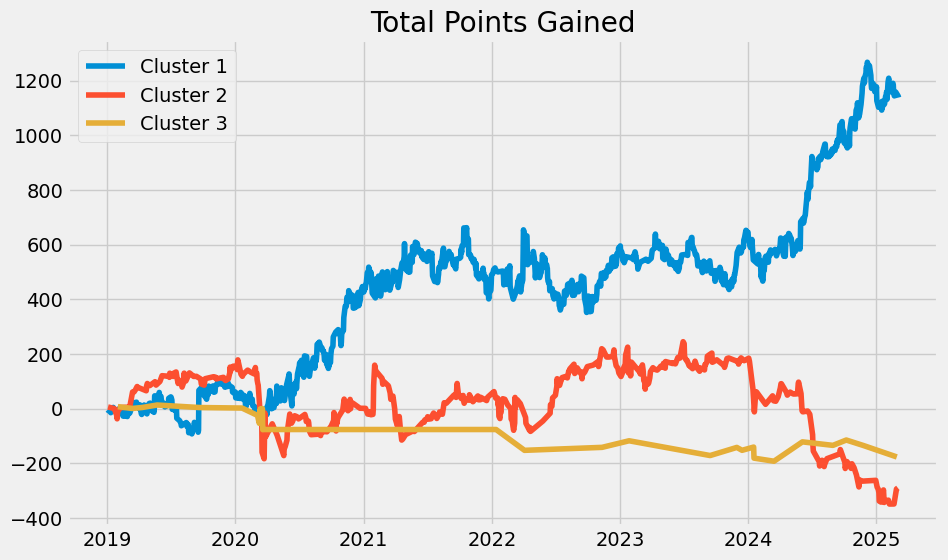

In [64]:
# Performance plot
plt.plot(np.cumsum(df_test['Return'].loc[df_test['Target'] == 0]),label='Cluster 1')
plt.plot(np.cumsum(df_test['Return'].loc[df_test['Target'] == 1]),label='Cluster 2')
plt.plot(np.cumsum(df_test['Return'].loc[df_test['Target'] == 2]),label='Cluster 3')
plt.title('Total Points Gained')
plt.legend()
plt.show()

Thus, buying on a cluster2 days resulted in outperformance during the testing period when compared to other two clusters. Further, trading in days following a classification into the low or high volatility clusters (1 & 3) would have resulted in sub-par returns and choppy volatility for the trading account since 2015.

# References

KMeans  
Silhouette Score  
Python Resources